# IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM

Consider the following input sentence, which has already been embedded into 3- dimensional vectors.

We choose a small embedding dimension for illustration purposes to ensure it fits on the page without line breaks:

In [31]:
import torch
import torch.nn as nn
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

Defining few variables:

**A**: The second input element

**B**: The input embedding size, d=3

**C**: The ouput embedding size, d_out=2

In [32]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #c

Note that in GPT-like models, the input and output dimensions are usually the same.

But for illustration purposes, to better follow the computation, we choose different input (d_in=3) and output (d_out=2) dimensions here.



Next, we initialize the three weight matrices Wq, Wk and Wv

In [33]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad = False)

In [34]:
print(W_query)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [35]:
print(W_key)

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])


In [36]:
print(W_value)

Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


Now lets try to get the query, key, value vectors by multiplying the 2nd element "journey" with the weights Wq, Wk and Wv

In [37]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)
print(key_2)
print(value_2)

tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor([0.3951, 1.0037])


Now we are doing the same above with all the elements

In [38]:
keys= inputs @ W_key
queries = inputs @ W_query
values = inputs @ W_value
print("keys.shape:",keys.shape)
print("queries.shape:", queries.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
queries.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


First, let's compute the attention score ω22

In [39]:
keys_2 = keys[1] #A
attn_score_22 = query_2 @ keys_2
print(attn_score_22)

tensor(1.8524)


Trying to generalize this computation to all attention scores via matrix multiplication:

In [40]:
attn_score_2 = query_2 @ keys.T #All attention scores for given query
print(attn_score_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [41]:
attn_scores = queries @ keys.T #omega
print(attn_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


We need to perform Normalization as from each row it looks its not interpretable as they do not sum up to 1.

For this we calculate the attention weights

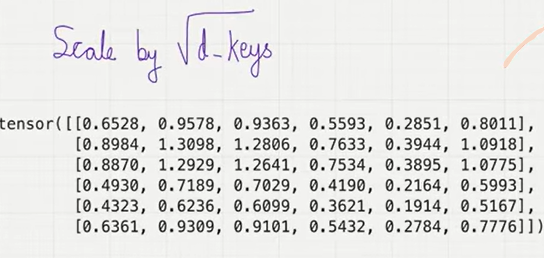

In [42]:
d_k = keys.shape[-1] #this is the keys we will be squarerooting and then using it to divide the attention scores obtained by applying softmax
#also we chose -1 because we are taking the dimension of column of this keys.shape which is [3,2] and we consider 2 as the dimention when we divide.
attn_weights_2 = torch.softmax(attn_score_2 / d_k**0.5, dim=-1)
print(attn_weights_2)
print(d_k)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
2


compute for all the row elements

In [43]:
d_k = keys.shape[-1] #this is the keys we will be squarerooting and then using it to divide the attention scores obtained by applying softmax
#also we chose -1 because we are taking the dimension of column of this keys.shape which is [3,2] and we consider 2 as the dimention when we divide.
attn_weights_2 = torch.softmax(attn_scores / d_k**0.5, dim=-1)
print(attn_weights_2)
print(d_k)

tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])
2


# WHY DIVIDE BY SQRT (DIMENSION)

Reason 1: For stability in learning

The softmax function is sensitive to the magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced. This causes the softmax output to become "peaky," where the highest value receives almost all the probability mass, and the rest receive very little.

In attention mechanisms, particularly in transformers, if the dot products between query and key vectors become too large (like multiplying by 8 in this example), the attention scores can become very large. This results in a very sharp softmax distribution, making the model overly confident in one particular "key." Such sharp distributions can make learning unstable,

In [44]:
import torch

# Define the tensor
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

# Apply softmax without scaling
softmax_result = torch.softmax(tensor, dim=-1)
print("Softmax without scaling:", softmax_result)

# Multiply the tensor by 8 and then apply softmax
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)
print("Softmax after scaling (tensor * 8):", softmax_scaled_result)

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


# BUT WHY SQRT?

Reason 2: To make the variance of the dot product stable

The dot product of Q and K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows with the dimension.

Dividing by sqrt (dimension) keeps the variance close to 1

In [45]:
import numpy as np

# Function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)

        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)

    # Calculate variance of the dot products
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling

# For dimension 5
variance_before_5, variance_after_5 = compute_variance(5)
print(f"Variance before scaling (dim=5): {variance_before_5}")
print(f"Variance after scaling (dim=5): {variance_after_5}")

# For dimension 20
variance_before_100, variance_after_100 = compute_variance(100)
print(f"Variance before scaling (dim=100): {variance_before_100}")
print(f"Variance after scaling (dim=100): {variance_after_100}")



Variance before scaling (dim=5): 4.922588696311283
Variance after scaling (dim=5): 0.9845177392622563
Variance before scaling (dim=100): 103.40903615017811
Variance after scaling (dim=100): 1.0340903615017811


We now compute the context vector as a weighted sum over the value vectors.

Here, the attention weights serve as a weighting factor that weighs the respective importance of each value vector.

We can use matrix multiplication to obtain the output in one step:

In [46]:
context_vector_2 = attn_weights_2 @ values
print(context_vector_2)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


So far, I only computed a single context vector, z(2).

Now I will generalize the code to compute all context vectors in the input sequence, z(1)to z (T)

# IMPLEMENTING A COMPACT SELF ATTENTION PYTHON CLASS

In the previous sections, we have gone through a lot of steps to compute the self-attention outputs.

This was mainly done for illustration purposes so we could go through one step at a time.

In practice, with the LLM implementation in the next chapter in mind, it is helpful to organize this code into a Python class as follows:

In [52]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in,d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    query = x @ self.W_query
    values = x @ self.W_value

    attn_scores = query @ keys.T
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim = -1)
    context_vec = attn_weights @ values
    return context_vec

In this PyTorch code, SelfAttention_v1 is a class derived from nn.Module, which is a fundamental building block of PyTorch models, which provides necessary functionalities for model layer creation and management.

The __init__ method initializes trainable weight matrices (W_query, W_key, and W_value) for queries, keys, and values, each transforming the input dimension d_in to an output dimension d_out.

During the forward pass, using the forward method, we compute the attention scores (attn_scores) by multiplying queries and keys, normalizing these scores using softmax.

Finally, create a context vector by weighting the values with these normalized attention scores.

In [53]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


Since inputs contains six embedding vectors, we get a matrix storing the six context vectors, as shown in the above result.

As a quick check, notice how the second row ([0.3061, 0.8210]) matches the contents of context_vec_2 in the previous section.

We can improve the SelfAttention_v1 implementation further by utilizing PyTorch's nn.Linear layers, which effectively perform matrix multiplication when the bias units are disabled.

Additionally, a significant advantage of using nn.Linear instead of manually implementing nn.Parameter(torch.rand(...)) is that nn.Linear has an optimized weight initialization scheme, contributing to more stable and effective model training.



In [54]:
class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias = qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias = qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias = qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    query = self.W_query(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim = -1)
    context_vec = attn_weights @ values
    return context_vec

In [55]:
torch.manual_seed(123)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.5260, -0.0964],
        [-0.5236, -0.0923],
        [-0.5236, -0.0925],
        [-0.5256, -0.0988],
        [-0.5245, -0.0996],
        [-0.5256, -0.0966]], grad_fn=<MmBackward0>)
